In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [4]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [6]:
df.dtypes

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object

Сгруппируйте данные по дате, посчитайте количество продаж

In [17]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество продаж')

Вывести несколько первых строк сгруппированных данных

In [37]:
grouped_df.head()

,Дата,Количество продаж
0,2018-01-04,1840
1,2018-01-05,1301
2,2018-01-06,1306
3,2018-01-07,1322
4,2018-01-09,1719


Нарисуйте график продаж у `grouped_df`

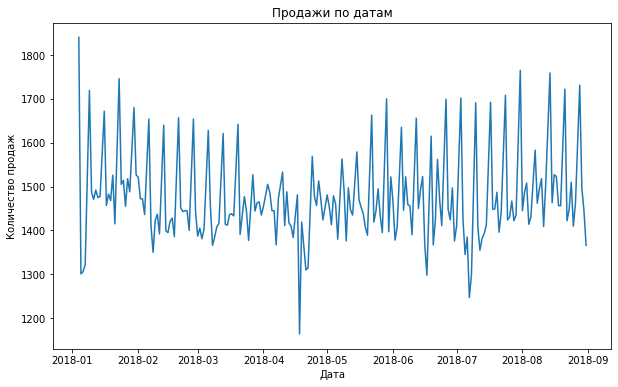

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(grouped_df['Дата'], grouped_df['Количество продаж'])
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.title('Продажи по датам')
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
Продажи стабильны на уровне около 1450–1500 без устойчивого роста или падения.
Есть сильная недельная сезонность, которую стоит проверить.
Есть аномалии (январь, середина апреля, начало июля).
Разброс значений меняется во времени: она ниже в марте–мае и выше летом.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [18]:
df.loc[df['Количество'].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [19]:
#склад №3
df2 = df[df['Склад'] == 3]

#июнь, июль и август
df2 = df2[df2['Дата'].dt.month.isin([6, 7, 8])]

#среда - по индексу 2ой
df2 = df2[df2['Дата'].dt.weekday == 2]

sales = df2.groupby('Номенклатура')['Количество'].sum()
print(sales.sort_values(ascending=False).head(1))

Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [20]:
print(df['Дата'].min())
print(df['Дата'].max())

2018-01-04 00:00:00
2018-08-31 00:00:00


In [30]:
weather = pd.read_excel('weather.xls')

In [31]:
weather.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN
1,31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN
2,31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN
3,31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,NaN,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN
4,31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,10.3,3,12.0,NaN,NaN,NaN,NaN


In [49]:
weather['Дата'] = pd.to_datetime(weather['Местное время в Астане'], dayfirst=True)

In [57]:
weather[['Дата', 'T']].head()

,Дата,T
0,2018-08-31 23:00:00,8.2
1,2018-08-31 20:00:00,9.6
2,2018-08-31 17:00:00,11.3
3,2018-08-31 14:00:00,12.3
4,2018-08-31 11:00:00,13.2


In [58]:
weather_daily = weather.groupby(weather['Дата'].dt.date)['T'].mean().reset_index()

In [60]:
weather_daily.head()

,Дата,T
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125


In [62]:
weather_daily['Дата'] = pd.to_datetime(weather_daily['Дата'])

In [63]:
merged_df = grouped_df.merge(weather_daily, on='Дата', how='left')

In [64]:
merged_df.head()

,Дата,Количество продаж,T
0,2018-01-04,1840,-14.0750
1,2018-01-05,1301,-16.8625
2,2018-01-06,1306,-13.3000
3,2018-01-07,1322,-12.7500
4,2018-01-09,1719,-6.2500


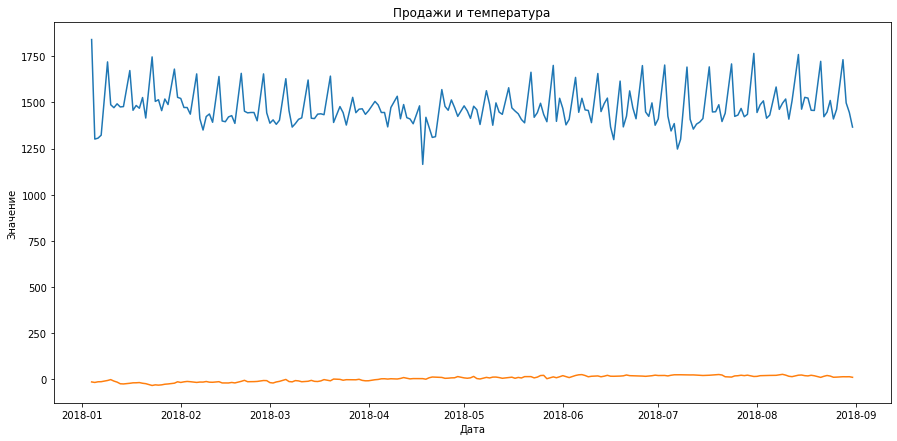

In [70]:
plt.figure(figsize=(15, 7))
plt.plot(merged_df['Дата'], merged_df['Количество продаж'])
plt.plot(merged_df['Дата'], merged_df['T'])

plt.xlabel('Дата')
plt.ylabel('Значение')
plt.title('Продажи и температура')
plt.show()

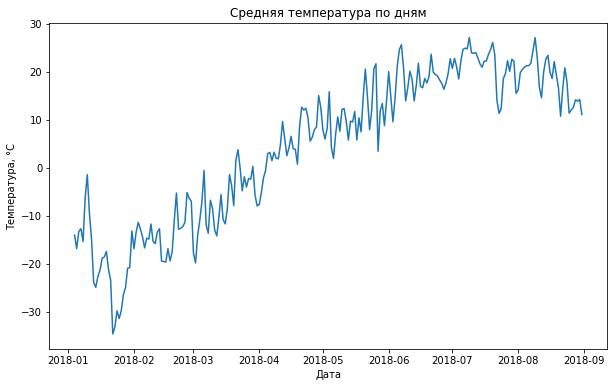

In [71]:
plt.figure(figsize=(10, 6))
plt.plot(weather_daily['Дата'], weather_daily['T'])
plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.title('Средняя температура по дням')
plt.show()